## Load data

Dark reference shape: (1, 512, 204)
White reference shape: (1, 512, 204)
Test image shape: (512, 512, 204)


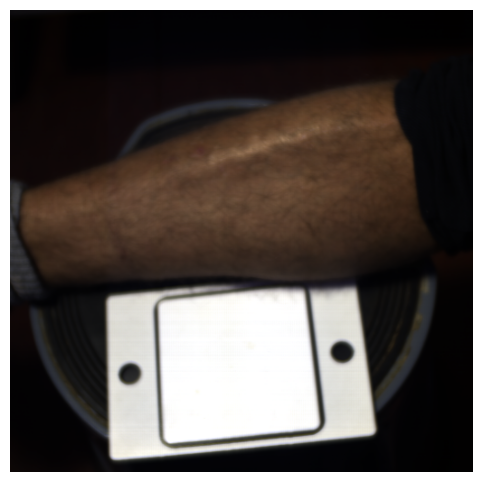

In [1]:
import spectral as spy
import numpy as np
import matplotlib.pyplot as plt


path_to_data = "/Users/StefZ/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents – Stef’s MacBook Pro/Morphos/Experiments/20260602 - HSI Bruise/Data/Raw/"
folder_name = "2026-06-09_006"
# Load the data
dark_data = spy.open_image(path_to_data + folder_name + "/capture/DARKREF_"+folder_name+".hdr").load()
white_data = spy.open_image(path_to_data + folder_name + "/capture/WHITEREF_"+folder_name+".hdr").load()
sample_data = spy.open_image(path_to_data + folder_name + "/capture/"+folder_name+".hdr").load()
print(f"Dark reference shape: {dark_data.shape}")
print(f"White reference shape: {white_data.shape}")
print(f"Test image shape: {sample_data.shape}")


# Extract spectrum from center of image
h, w, bands = sample_data.shape
# # Create wavelength array (Specim IQ: 400-1000 nm, 204 bands)
wavelengths = np.linspace(400, 1000, bands)


plt.figure(figsize=(12, 6))
plt.imshow(plt.imread(path_to_data + folder_name + "/"+folder_name+".png"))
plt.axis("off")
plt.show()

## Calibrate data

In [6]:

sample_data = sample_data.astype(np.float32)
dark_data = dark_data.astype(np.float32)
white_data = white_data.astype(np.float32)
# Calculate mean dark and white values across spatial dimensions
# Add small epsilon (1e-8) to avoid division by zero
calibrated = np.divide(sample_data - dark_data, white_data - dark_data + 1e-8)
print(f"np.mean(sample_data): {np.mean(sample_data)}")
print(f"np.mean(dark_data): {np.mean(dark_data)}")
print(f"np.mean(white_data): {np.mean(white_data)}")
print(f"np.mean(calibrated): {np.mean(calibrated)}")

np.mean(sample_data): 672.3091430664062
np.mean(dark_data): 239.6321258544922
np.mean(white_data): 1739.88232421875
np.mean(calibrated): 0.29824069142341614


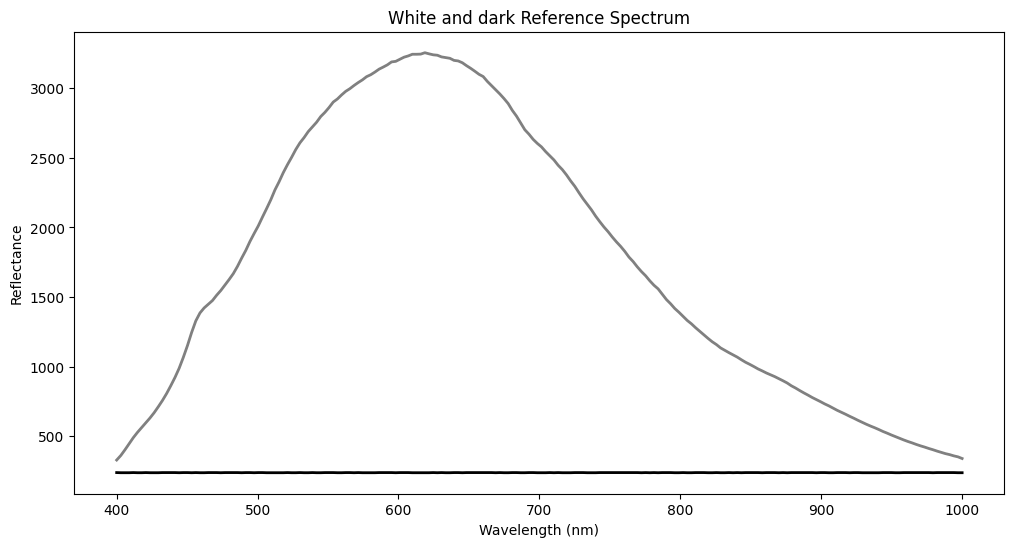

In [7]:
# Plot white reference spectrum 
plt.figure(figsize=(12, 6))
plt.title("White and dark Reference Spectrum")
plt.plot(wavelengths, np.squeeze(white_data[0,256,:]), linewidth=2, color='gray')
plt.plot(wavelengths, np.squeeze(dark_data[0,256,:]), linewidth=2, color='black')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.show()
# white_data.shape

## Visualize spectrum for single pixel (e.g., center pixel)

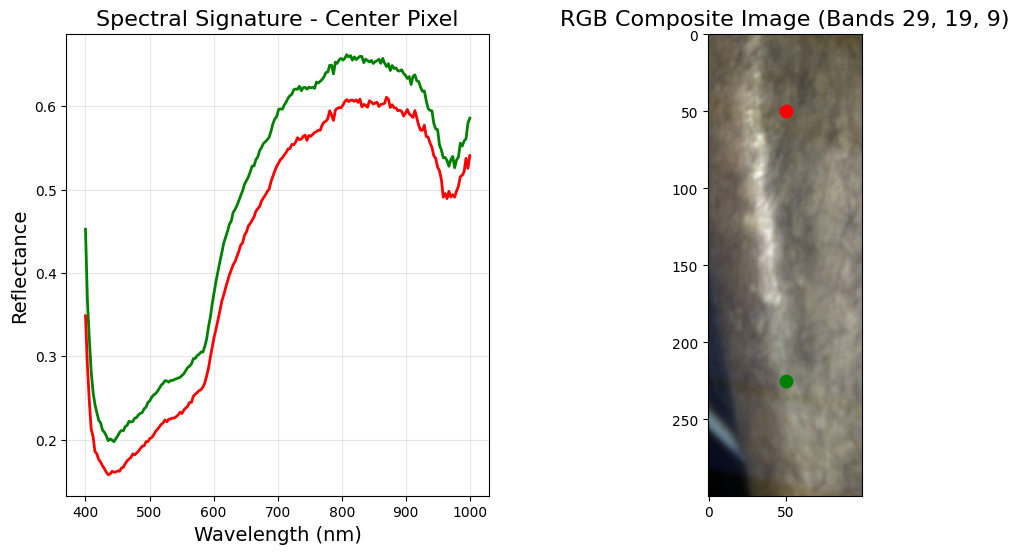

In [9]:
from scipy.ndimage import rotate

roi_calibrated = rotate(calibrated, -10, axes=(0, 1), reshape=False)
roi_calibrated = roi_calibrated[100:400, 120:220, :]
rgb = spy.get_rgb(roi_calibrated, [29, 19, 9])
center_y, center_x = 225, roi_calibrated.shape[1] // 2
# Plot spectrum
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(wavelengths, np.squeeze(roi_calibrated[center_y, center_x, :]), linewidth=2, color='green')
plt.plot(wavelengths, np.squeeze(roi_calibrated[50, 50, :]), linewidth=2, color='red')
plt.xlabel('Wavelength (nm)', fontsize=14)
plt.ylabel('Reflectance', fontsize=14)
plt.title('Spectral Signature - Center Pixel', fontsize=16)
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.imshow(rgb)
plt.title('RGB Composite Image (Bands 29, 19, 9)', fontsize=16)
plt.scatter(center_x, center_y, c='green', s=80, marker='o')
plt.scatter(50,50, c='red', s=80, marker='o')
# plt.axis('off')

# Save spectrum plot
# print("Spectrum plot saved: center_pixel_spectrum.png")
plt.show()

## Image for a specific wavelength

In [10]:
import ipywidgets as widgets
from IPython.display import display
band = 100  # default band index
def show_band(b):
    plt.figure(figsize=(12, 6))
    plt.imshow(roi_calibrated[:, :, b], cmap='gray')
    plt.title(f"Test Image (Band {b}, wavelength {wavelengths[b]:.1f} nm)")
    plt.axis("off")
    plt.show()

band_slider = widgets.IntSlider(
    value=band,
    min=0,
    max=roi_calibrated.shape[2] - 1,
    step=1,
    description="Band",
    continuous_update=True
)

widgets.interactive_output(show_band, {"b": band_slider})
band_slider.unobserve_all()  # avoid duplicate callbacks
out = widgets.interactive_output(show_band, {"b": band_slider})
display(widgets.VBox([band_slider, out]))

## QUALITY CHECKS


In [6]:


print("\n" + "="*50)
print("CALIBRATION QUALITY CHECKS")
print("="*50)
dark_mean = np.mean(dark_data, axis=(0, 1))
white_mean = np.mean(white_data, axis=(0, 1))
# Check 1: Dark reference should be near zero
dark_mean_value = np.mean(dark_mean)
print(f"Dark reference mean: {dark_mean_value:.4f} (should be near 0)")

# Check 2: White reference should be significantly higher than dark
white_mean_value = np.mean(white_mean)
print(f"White reference mean: {white_mean_value:.4f}")

# Check 3: Dynamic range
dynamic_range = white_mean_value - dark_mean_value
print(f"Dynamic range: {dynamic_range:.4f}")

# Check 4: Calibrated values should be mostly between 0 and 1
valid_pixels = np.sum((calibrated >= 0) & (calibrated <= 1.2))
total_pixels = calibrated.size
percent_valid = 100 * valid_pixels / total_pixels
print(f"Valid calibrated pixels: {percent_valid:.1f}%")

if percent_valid > 95:
    print("\nCalibration quality: EXCELLENT")
elif percent_valid > 85:
    print("\nCalibration quality: GOOD (minor issues)")
else:
    print("\nCalibration quality: POOR (recapture references)")

print("="*50)



CALIBRATION QUALITY CHECKS
Dark reference mean: 239.6321 (should be near 0)
White reference mean: 1739.8823
Dynamic range: 1500.2502
Valid calibrated pixels: 100.0%

Calibration quality: EXCELLENT


## K-means clustering

In [7]:
# Region of interest: x = 100:200, y = 200:500
# roi_calibrated = calibrated[200:500, 100:200, :]

# Reshape ROI hypercube to (num_pixels, num_bands)
roi_X = roi_calibrated.reshape(-1, roi_calibrated.shape[2])

print(f"ROI calibrated shape: {roi_calibrated.shape}")
print(f"ROI reshaped shape: {roi_X.shape}")


ROI calibrated shape: (300, 100, 204)
ROI reshaped shape: (30000, 204)


K-means done: 4 clusters
Cluster map shape: (300, 100)


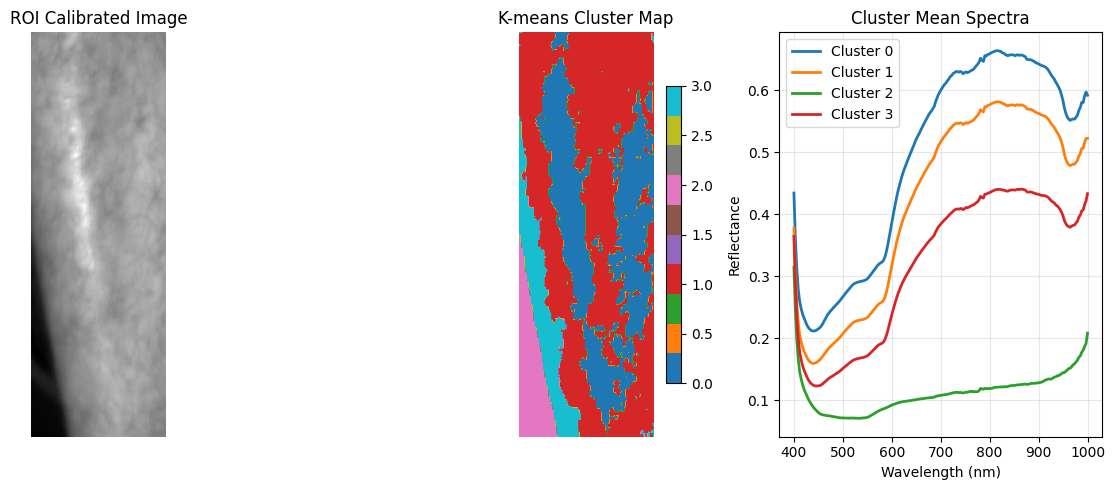

In [8]:
from sklearn.cluster import KMeans

# Reshape hypercube to (num_pixels, num_bands)
roi_X = roi_calibrated.reshape(-1, roi_calibrated.shape[2])

# K-means clustering
n_clusters = 4  # change if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(roi_X)

# Reshape labels back to image space
cluster_map = labels.reshape(roi_calibrated.shape[0], roi_calibrated.shape[1])
cluster_centers = kmeans.cluster_centers_

print(f"K-means done: {n_clusters} clusters")
print(f"Cluster map shape: {cluster_map.shape}")

# Visualize cluster map
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(roi_calibrated[:, :, band], cmap='gray')
plt.title("ROI Calibrated Image")
plt.axis("off")
plt.subplot(1, 3, 2)   
plt.imshow(cluster_map, cmap="tab10")
plt.title("K-means Cluster Map")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# Visualize mean spectrum per cluster
plt.subplot(1, 3, 3)
for c in range(n_clusters):
    plt.plot(wavelengths, cluster_centers[c], linewidth=2, label=f"Cluster {c}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Cluster Mean Spectra")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Otsumethod
Segmenteer background, en trace
Doe dit per golfrengte, zodat je me meeste contrast kunt berekenen tussen de trace en de background.

Absorbance bekijken (-log van de reflectance)


## Band ratios


In [11]:
# Interactive band-ratio viewer: ratio = band_A / band_B
band_A = 55
band_B = 26

def show_ratio(a, b):
    ratio = roi_calibrated[:, :, a] / (roi_calibrated[:, :, b] + 1e-8)

    # Robust display scaling (avoids outliers dominating contrast)
    vmin, vmax = np.percentile(ratio, [1, 99])

    plt.figure(figsize=(12, 6))
    im = plt.imshow(ratio, cmap="inferno", vmin=vmin, vmax=vmax)
    plt.title(
        f"Band ratio: A/B = {a}/{b} "
        f"({wavelengths[a]:.1f} nm / {wavelengths[b]:.1f} nm)"
    )
    plt.axis("off")
    plt.show()

band_slider_a = widgets.IntSlider(
    value=band_A,
    min=0,
    max=calibrated.shape[2] - 1,
    step=1,
    description="Band A",
    continuous_update=True
)
band_slider_b = widgets.IntSlider(
    value=band_B,
    min=0,
    max=calibrated.shape[2] - 1,
    step=1,
    description="Band B",
    continuous_update=True
)

widgets.interactive_output(show_ratio, {"a": band_slider_a, "b": band_slider_b})
band_slider_a.unobserve_all()  # avoid duplicate callbacks
band_slider_b.unobserve_all()  # avoid duplicate callbacks
out = widgets.interactive_output(show_ratio, {"a": band_slider_a, "b": band_slider_b})
display(widgets.VBox([band_slider_a, band_slider_b, out]))

## Normalized difference Indices    

In [10]:
# Interactive band-ratio viewer: ratio = band_A / band_B
band_A = 55
band_B = 26

def show_ratio(a, b):
    ratio = np.divide(roi_calibrated[:, :, a] - roi_calibrated[:, :, b], roi_calibrated[:, :, a] + roi_calibrated[:, :, b] + 1e-8)

    # Robust display scaling (avoids outliers dominating contrast)
    vmin, vmax = np.percentile(ratio, [1, 99])

    plt.figure(figsize=(12, 6))
    im = plt.imshow(ratio, cmap="inferno", vmin=vmin, vmax=vmax)
    plt.title(
        f"Band ratio: A/B = {a}/{b} "
        f"({wavelengths[a]:.1f} nm / {wavelengths[b]:.1f} nm)"
    )
    # plt.axis("off")
    plt.show()

band_slider_a = widgets.IntSlider(
    value=band_A,
    min=0,
    max=calibrated.shape[2] - 1,
    step=1,
    description="Band A",
    continuous_update=True
)
band_slider_b = widgets.IntSlider(
    value=band_B,
    min=0,
    max=calibrated.shape[2] - 1,
    step=1,
    description="Band B",
    continuous_update=True
)

widgets.interactive_output(show_ratio, {"a": band_slider_a, "b": band_slider_b})
band_slider_a.unobserve_all()  # avoid duplicate callbacks
band_slider_b.unobserve_all()  # avoid duplicate callbacks
out = widgets.interactive_output(show_ratio, {"a": band_slider_a, "b": band_slider_b})
display(widgets.VBox([band_slider_a, band_slider_b, out]))

## PCA 

PCA completed
Explained variance ratio: [9.792e-01 1.470e-02 3.500e-03 1.200e-03 4.000e-04 2.000e-04]
Cumulative explained variance: [0.9792 0.9939 0.9974 0.9986 0.9989 0.9992]


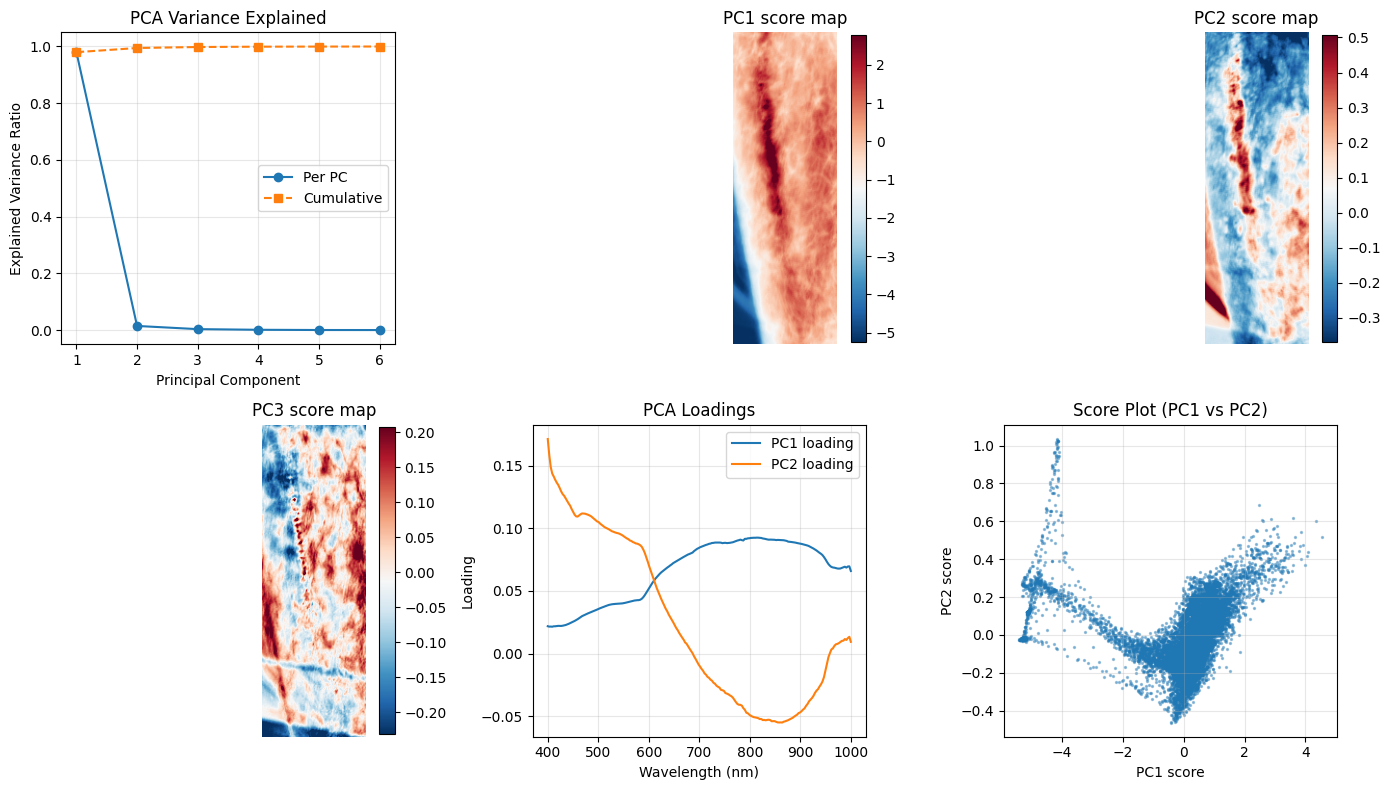

In [11]:
from sklearn.decomposition import PCA

# Flatten ROI cube: (rows, cols, bands) -> (pixels, bands)
h_roi, w_roi, n_bands = roi_calibrated.shape
roi_pixels = roi_calibrated.reshape(-1, n_bands)

# Mean-center spectra (common for hyperspectral PCA)
roi_pixels_centered = roi_pixels - roi_pixels.mean(axis=0, keepdims=True)

# PCA
n_pcs = 6
pca = PCA(n_components=n_pcs, random_state=42)
pca_scores = pca.fit_transform(roi_pixels_centered)          # (pixels, n_pcs)
pca_loadings = pca.components_                               # (n_pcs, bands)
explained_var = pca.explained_variance_ratio_               # (n_pcs,)

# Reshape PCA scores back to image maps
pc_maps = pca_scores.reshape(h_roi, w_roi, n_pcs)

print("PCA completed")
print("Explained variance ratio:", np.round(explained_var, 4))
print("Cumulative explained variance:", np.round(np.cumsum(explained_var), 4))

# --- Visualizations ---
plt.figure(figsize=(14, 8))

# 1) Explained variance
plt.subplot(2, 3, 1)
plt.plot(np.arange(1, n_pcs + 1), explained_var, "o-", label="Per PC")
plt.plot(np.arange(1, n_pcs + 1), np.cumsum(explained_var), "s--", label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Variance Explained")
plt.grid(alpha=0.3)
plt.legend()

# 2) PC score maps (first 3 PCs)
for i in range(3):
    ax = plt.subplot(2, 3, i + 2)
    img = pc_maps[:, :, i]
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(f"PC{i+1} score map")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 3) Loadings (first 2 PCs)
plt.subplot(2, 3, 5)
plt.plot(wavelengths, pca_loadings[0], label="PC1 loading")
plt.plot(wavelengths, pca_loadings[1], label="PC2 loading")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Loading")
plt.title("PCA Loadings")
plt.grid(alpha=0.3)
plt.legend()

# 4) PC1 vs PC2 scatter (subsample for speed)
plt.subplot(2, 3, 6)
step = max(1, pca_scores.shape[0] // 10000)
plt.scatter(pca_scores[::step, 0], pca_scores[::step, 1], s=2, alpha=0.4)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Score Plot (PC1 vs PC2)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Minimum Noise Fraction (MNF)


MNF completed
Eigenvalues (noise-to-signal ratio): [1.69683660e+06 1.42056884e+04 6.39012780e+03 8.21099100e+02
 3.87118300e+02 2.61239300e+02 1.22359700e+02 9.34816000e+01
 2.94171000e+01 2.01315000e+01]


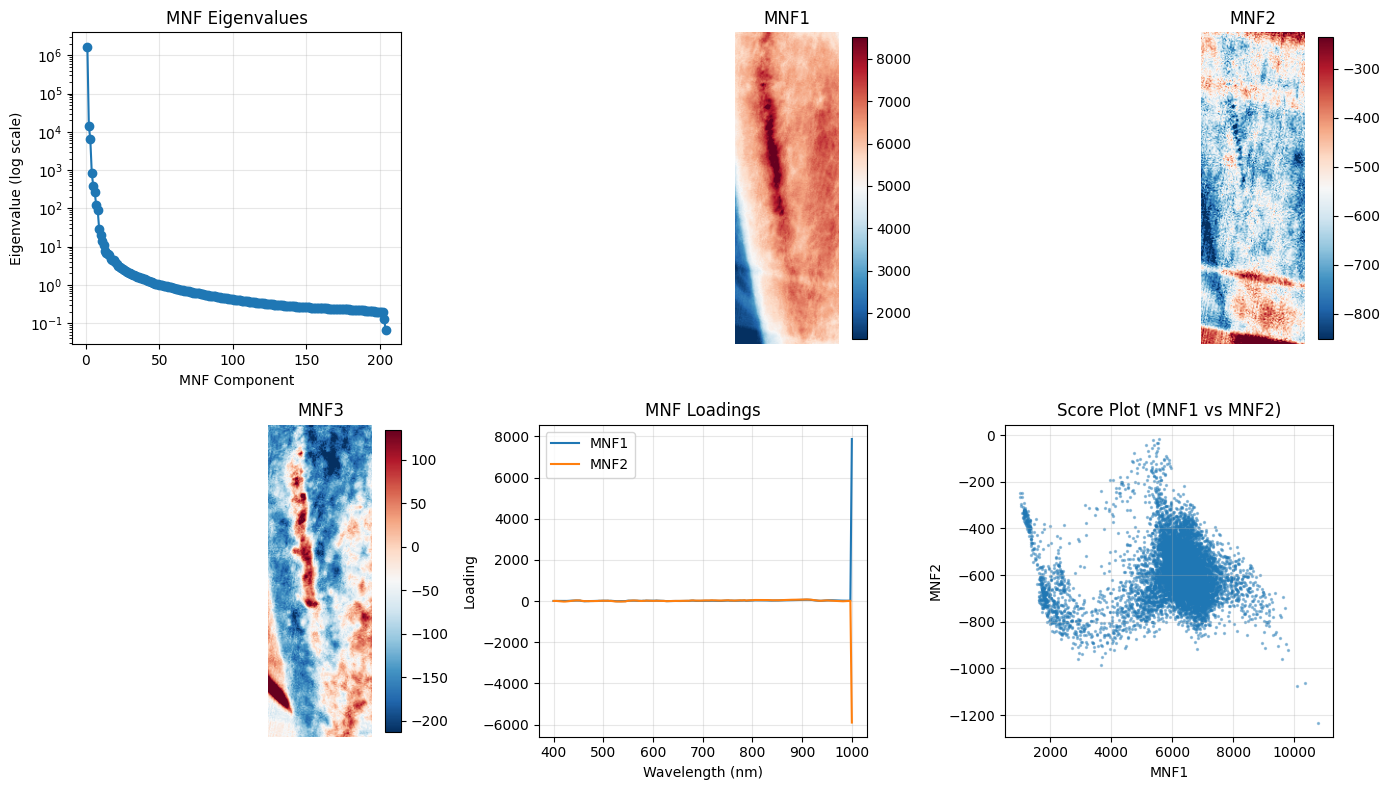

In [12]:
from sklearn.covariance import EmpiricalCovariance
from scipy.linalg import eigh

# Flatten ROI cube: (rows, cols, bands) -> (pixels, bands)
h_roi, w_roi, n_bands_roi = roi_calibrated.shape
roi_pixels_mnf = roi_calibrated.reshape(-1, n_bands_roi)

# Estimate noise covariance (using difference between adjacent bands)
noise_cov = np.cov((roi_pixels_mnf[:, 1:] - roi_pixels_mnf[:, :-1]).T)

# Estimate signal covariance
signal_cov = np.cov(roi_pixels_mnf.T)

# Regularize noise covariance to avoid singularity
noise_cov_reg = noise_cov + np.eye(n_bands_roi - 1) * 1e-6

# Compute MNF transformation matrix (generalized eigenvalue problem)
# We need to solve: signal_cov * w = lambda * noise_cov * w

# Pad noise_cov to match signal_cov dimensions
noise_cov_padded = np.zeros((n_bands_roi, n_bands_roi))
noise_cov_padded[:-1, :-1] = noise_cov_reg

eigenvalues, eigenvectors = eigh(signal_cov, noise_cov_padded + np.eye(n_bands_roi) * 1e-8)

# Sort by eigenvalues in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Apply MNF transformation
mnf_scores = roi_pixels_mnf @ eigenvectors  # (pixels, n_bands)
mnf_maps = mnf_scores.reshape(h_roi, w_roi, n_bands_roi)

print("MNF completed")
print("Eigenvalues (noise-to-signal ratio):", np.round(eigenvalues[:10], 4))

# --- Visualizations ---
plt.figure(figsize=(14, 8))

# 1) Eigenvalues
plt.subplot(2, 3, 1)
plt.semilogy(np.arange(1, n_bands_roi + 1), eigenvalues, "o-")
plt.xlabel("MNF Component")
plt.ylabel("Eigenvalue (log scale)")
plt.title("MNF Eigenvalues")
plt.grid(alpha=0.3)

# 2) MNF component maps (first 3)
for i in range(3):
    ax = plt.subplot(2, 3, i + 2)
    img = mnf_maps[:, :, i]
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(f"MNF{i+1}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 3) MNF loadings (first 2 components)
plt.subplot(2, 3, 5)
plt.plot(wavelengths, eigenvectors[:, 0], label="MNF1")
plt.plot(wavelengths, eigenvectors[:, 1], label="MNF2")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Loading")
plt.title("MNF Loadings")
plt.grid(alpha=0.3)
plt.legend()

# 4) Scatterplot MNF1 vs MNF2
plt.subplot(2, 3, 6)
step = max(1, mnf_scores.shape[0] // 10000)
plt.scatter(mnf_scores[::step, 0], mnf_scores[::step, 1], s=2, alpha=0.4)
plt.xlabel("MNF1")
plt.ylabel("MNF2")
plt.title("Score Plot (MNF1 vs MNF2)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. False-color composites with PCA components

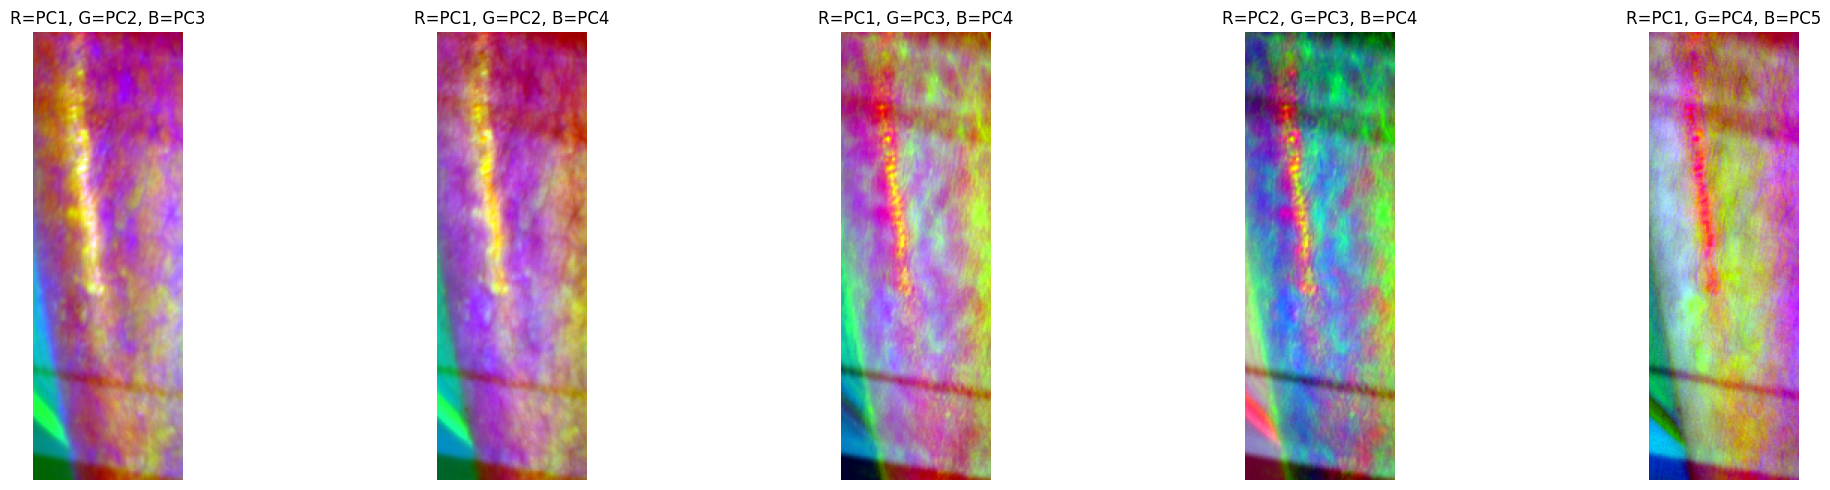

In [13]:
# 5 false-color composites using PCA components from roi_calibrated

# Ensure we have enough PCA components
h_roi, w_roi, n_bands_roi = roi_calibrated.shape
roi_pixels = roi_calibrated.reshape(-1, n_bands_roi)
roi_pixels_centered = roi_pixels - roi_pixels.mean(axis=0, keepdims=True)

pca_fc = PCA(n_components=6, random_state=42)
scores_fc = pca_fc.fit_transform(roi_pixels_centered)
pc_maps_fc = scores_fc.reshape(h_roi, w_roi, 6)

def robust_norm(img, p1=1, p99=99):
    lo, hi = np.percentile(img, [p1, p99])
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

# Choose 5 RGB combinations of PCs
pc_combos = [
    (0, 1, 2),  # PC1, PC2, PC3
    (0, 1, 3),  # PC1, PC2, PC4
    (0, 2, 3),  # PC1, PC3, PC4
    (1, 2, 3),  # PC2, PC3, PC4
    (0, 3, 4),  # PC1, PC4, PC5
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (r, g, b) in zip(axes, pc_combos):
    rgb_fc = np.dstack([
        robust_norm(pc_maps_fc[:, :, r]),
        robust_norm(pc_maps_fc[:, :, g]),
        robust_norm(pc_maps_fc[:, :, b]),
    ])
    ax.imshow(rgb_fc)
    ax.set_title(f"R=PC{r+1}, G=PC{g+1}, B=PC{b+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Spectral angle mapper

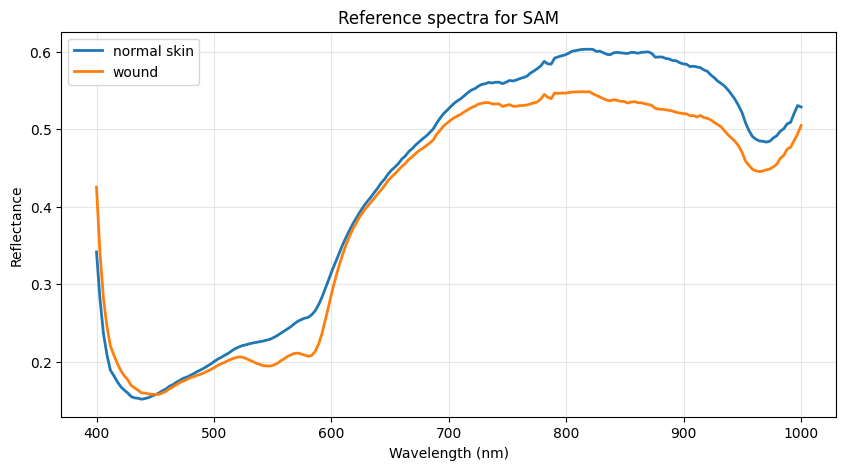

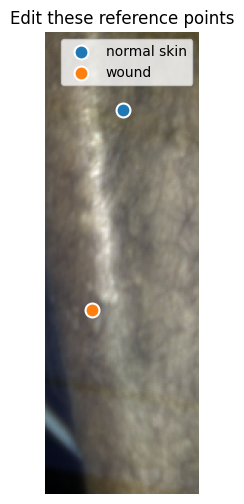

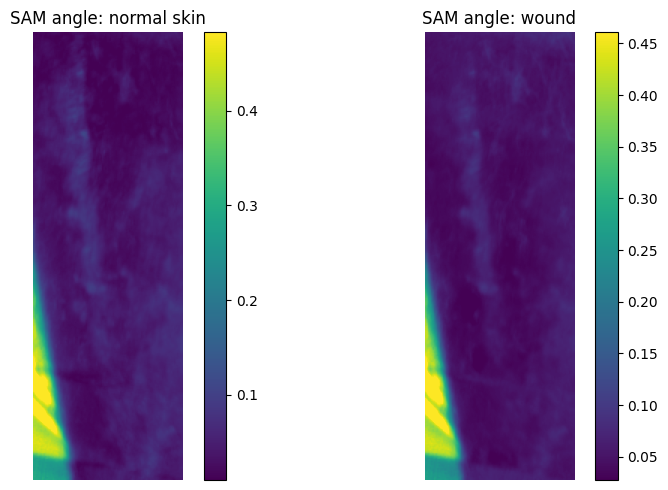

/var/folders/d4/gc9c__3j77lb7kfgprl2dt500000gn/T/ipykernel_3429/3647096966.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(sam_class_map_masked, cmap=plt.cm.get_cmap("Set1", len(class_names)), vmin=0, vmax=len(class_names)-1)


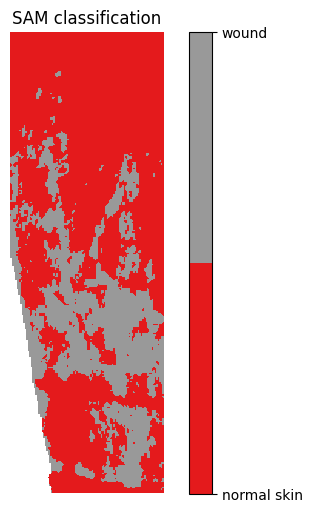

SAM completed
normal skin: reference point=(50, 50)
wound: reference point=(180, 30)


In [14]:
# Spectral Angle Mapper (SAM) on roi_calibrated
# Edit the coordinates below to your own reference pixels.
# Coordinates are (row, col) inside roi_calibrated.

reference_points = {
    "normal skin": (50, 50),
    "wound": (180, 30),
}

window_radius = 3          # average spectra in a small window around each point
sam_threshold_deg = 0.12   # set to None to disable "unclassified" masking

def extract_mean_spectrum(cube, row, col, radius=3):
    r0 = max(0, row - radius)
    r1 = min(cube.shape[0], row + radius + 1)
    c0 = max(0, col - radius)
    c1 = min(cube.shape[1], col + radius + 1)
    return cube[r0:r1, c0:c1, :].mean(axis=(0, 1))

def spectral_angle_map(cube, endmembers):
    h, w, b = cube.shape
    pixels = cube.reshape(-1, b).astype(np.float32)

    pixel_norms = np.linalg.norm(pixels, axis=1, keepdims=True) + 1e-8
    pixels_unit = pixels / pixel_norms

    angles = []
    for spectrum in endmembers:
        spectrum = spectrum.astype(np.float32)
        spectrum_unit = spectrum / (np.linalg.norm(spectrum) + 1e-8)
        cosang = np.clip(pixels_unit @ spectrum_unit, -1.0, 1.0)
        angles.append(np.arccos(cosang))

    angles = np.stack(angles, axis=1)  # (n_pixels, n_classes)
    return angles.reshape(h, w, -1)

# Extract reference spectra
class_names = list(reference_points.keys())
reference_spectra = np.array([
    extract_mean_spectrum(roi_calibrated, row, col, radius=window_radius)
    for row, col in reference_points.values()
])

# Run SAM
sam_angles = spectral_angle_map(roi_calibrated, reference_spectra)
sam_min_angle = np.min(sam_angles, axis=2)
sam_class_map = np.argmin(sam_angles, axis=2)

if sam_threshold_deg is not None:
    sam_class_map_masked = sam_class_map.astype(float)
    sam_class_map_masked[sam_min_angle > sam_threshold_deg] = np.nan
else:
    sam_class_map_masked = sam_class_map

# Use existing RGB if available, otherwise create it
if "rgb" in globals() and rgb.shape[:2] == roi_calibrated.shape[:2]:
    rgb_view = rgb
else:
    rgb_view = spy.get_rgb(roi_calibrated, [29, 19, 9])

# Plot reference spectra
plt.figure(figsize=(10, 5))
for i, name in enumerate(class_names):
    plt.plot(wavelengths, reference_spectra[i], linewidth=2, label=name)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Reference spectra for SAM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot RGB with selected reference points
plt.figure(figsize=(8, 6))
plt.imshow(rgb_view)
for name, (row, col) in reference_points.items():
    plt.scatter(col, row, s=100, label=name, edgecolor="white", linewidth=1.5)
plt.title("Edit these reference points")
plt.axis("off")
plt.legend()
plt.show()

# Plot per-class angle maps
fig, axes = plt.subplots(1, len(class_names), figsize=(5 * len(class_names), 5))
if len(class_names) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    img = sam_angles[:, :, i]
    vmin_i, vmax_i = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="viridis", vmin=vmin_i, vmax=vmax_i)
    ax.set_title(f"SAM angle: {class_names[i]}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Plot final classification
class_colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(sam_class_map_masked, cmap=plt.cm.get_cmap("Set1", len(class_names)), vmin=0, vmax=len(class_names)-1)
ax.set_title("SAM classification")
ax.axis("off")

cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(class_names)), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names)

plt.show()

print("SAM completed")
for i, name in enumerate(class_names):
    print(f"{name}: reference point={reference_points[name]}")